In [ ]:
# %pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 21.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'japanize-matplotlib' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'japanize-matplotlib'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120306 sha256=b8fbbbb1990601a5d2537d4bba1e5246970545bee908043beb97ccdb31b6d064
  Stored in directory: /home/rkaneko/.cache/pip/wheels/61/7a/6b/df1f79be9c59862525070e157e62b08eab8ece27c1b68fbb94
Successfully built japanize-matplotlib
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import japanize_matplotlib

In [3]:
# モデル読み込み
pt_model_path = "../dense.pt"
dense_model = models.resnet18()
dense_model.fc = nn.Linear(dense_model.fc.in_features, 10)  # CIFAR-10 にあわせて出力層変更
dense_model.load_state_dict(torch.load(pt_model_path))

<All keys matched successfully>

--- Layer: layer4.1.conv2 (Shape: (512, 512, 3, 3)) ---


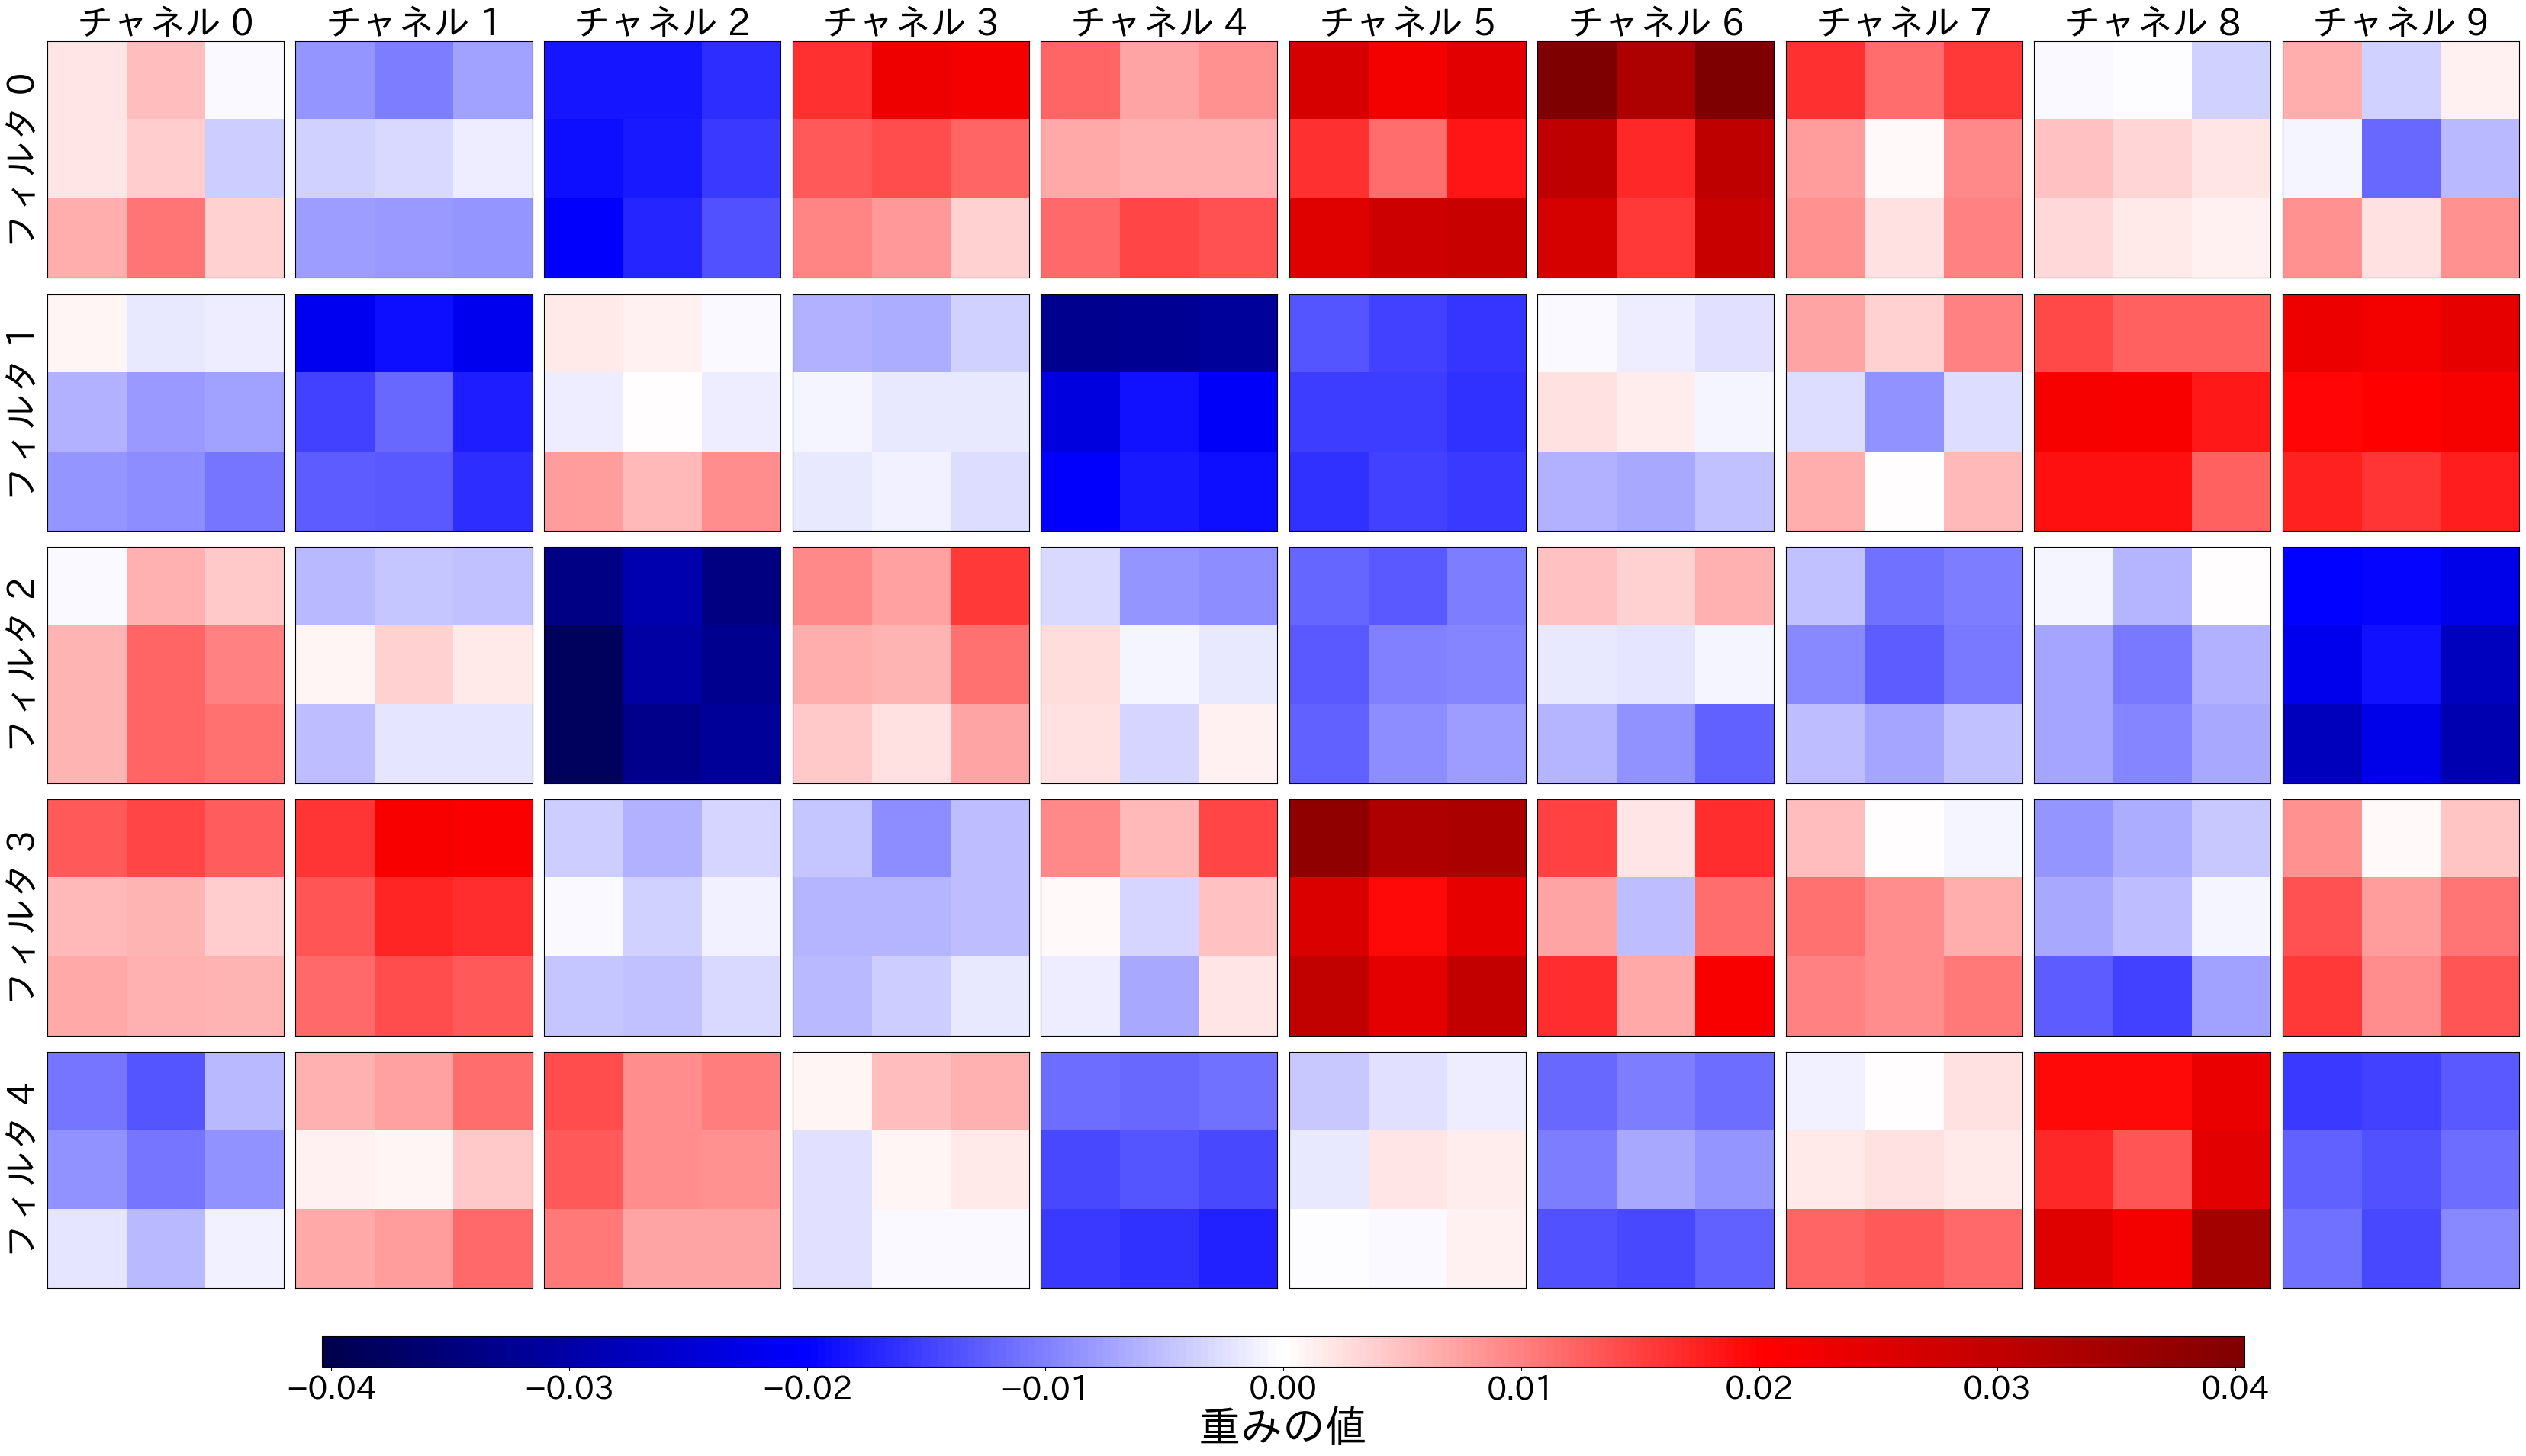

In [6]:
# 1. モデルのモジュールをループ
for name, module in dense_model.named_modules():

    # 2. Conv2d かつ カーネルサイズが 7x7 (Conv1想定) か判定
    if isinstance(module, nn.Conv2d) and name == "layer4.1.conv2":
        
        # 重みデータを取得 [Out_Channels, In_Channels, H, W]
        # shape例: [64, 3, 7, 7]
        weights = module.weight.data.cpu().numpy()
        
        # 表示する数（フィルタ数10、チャンネル数3）
        num_filters = 5
        num_channels = 10
        
        print(f"--- Layer: {name} (Shape: {weights.shape}) ---")

        # 10行(フィルタ) x 3列(チャンネル) の大きな図を作成
        fig, axes = plt.subplots(num_filters, num_channels, figsize=(36, 20))
        plt.subplots_adjust(wspace=0.05, hspace=0.05, bottom=0.1, top=0.92, left=0.05, right=0.95)
        
        # 表示する全データの最大絶対値を計算（全体の色基準を統一するため）
        # ※ 個別に正規化したい場合は、ループ内で vmax を計算してください
        w_subset = weights[:num_filters, :num_channels, :, :]
        vmax = np.abs(w_subset).max()

        for f_idx in range(num_filters):     # 行：フィルタのループ
            for c_idx in range(num_channels): # 列：チャンネルのループ
                
                ax = axes[f_idx, c_idx]
                
                # 7x7 カーネルを取り出す
                w_kernel = weights[f_idx, c_idx]
                
                # ヒートマップ表示
                im = ax.imshow(w_kernel, cmap='seismic', vmin=-vmax, vmax=vmax)
                
                # 軸の目盛りを消す（見やすくするため）
                ax.set_xticks([])
                ax.set_yticks([])
                
                # 最初の行だけにチャンネル名のタイトルをつける
                if f_idx == 0:
                    ax.set_title(f"チャネル {c_idx}", fontsize=34)
                
                # 最初の列だけにフィルタ番号のラベルをつける（左側）
                if c_idx == 0:
                    ax.set_ylabel(f"フィルタ {f_idx}", fontsize=34, rotation=90, labelpad=5)
        
        # カラーバーを一つだけ下部に追加（オプション）
        cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02]) # [left, bottom, width, height]
        fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
        cbar_ax.tick_params(labelsize=30)
        cbar_ax.set_xlabel("重みの値", fontsize=40)

        #plt.suptitle(f"First 10 Filters of {name} (Dense Model)", y=1.005, fontsize=24)
        plt.show()

        # 最初の該当層だけで終了
        break